# 4.9 캐글 산탄데르 고객 만족 예측

## 1. 문제 정의

산탄데르 고객 만족 데이터셋을 이용하여 고객의 만족 여부를 예측하는 분류 문제이다.

TARGET 값은 고객의 만족 여부를 나타내며,
- 0: 만족
- 1: 불만족

을 의미한다.

데이터는 총 370개의 피처로 이루어져 있으며, 모델의 성능은 ROC-AUC를 기준으로 평가한다.

### 전체 실습 과정

데이터 확인
→ 데이터 전처리
→ 학습/테스트 데이터 분리
→ XGBoost 학습
→ HyperOpt를 이용한 하이퍼파라미터 튜닝
→ XGBoost 최종 모델 평가
→ 피처 중요도 확인
→ LightGBM 학습
→ HyperOpt를 이용한 하이퍼파라미터 튜닝
→ LightGBM 최종 모델 평가

## 2. 데이터 로딩 및 확인

먼저 데이터를 불러와 데이터의 크기와 구조를 확인한다.
각 행은 한 고객의 데이터를 의미하며, 마지막 TARGET 열이 예측해야 할 값이다.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import warnings

warnings.filterwarnings('ignore')
cust_df = pd.read_csv('/content/train.csv', encoding='latin-1')

print('dataset shape:', cust_df.shape)
cust_df.head(3)

dataset shape: (76020, 371)


,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,imp_op_var40_ult1,imp_op_var41_comer_ult1,imp_op_var41_comer_ult3,imp_op_var41_efect_ult1,imp_op_var41_efect_ult3,imp_op_var41_ult1,imp_op_var39_efect_ult1,imp_op_var39_efect_ult3,imp_op_var39_ult1,imp_sal_var16_ult1,ind_var1_0,ind_var1,ind_var2_0,ind_var2,ind_var5_0,ind_var5,ind_var6_0,ind_var6,ind_var8_0,ind_var8,ind_var12_0,ind_var12,ind_var13_0,ind_var13_corto_0,ind_var13_corto,ind_var13_largo_0,ind_var13_largo,ind_var13_medio_0,ind_var13_medio,ind_var13,ind_var14_0,ind_var14,ind_var17_0,ind_var17,ind_var18_0,ind_var18,ind_var19,ind_var20_0,ind_var20,ind_var24_0,...,num_trasp_var33_out_ult1,num_venta_var44_hace3,num_venta_var44_ult1,num_var45_hace2,num_var45_hace3,num_var45_ult1,num_var45_ult3,saldo_var2_ult1,saldo_medio_var5_hace2,saldo_medio_var5_hace3,saldo_medio_var5_ult1,saldo_medio_var5_ult3,saldo_medio_var8_hace2,saldo_medio_var8_hace3,saldo_medio_var8_ult1,saldo_medio_var8_ult3,saldo_medio_var12_hace2,saldo_medio_var12_hace3,saldo_medio_var12_ult1,saldo_medio_var12_ult3,saldo_medio_var13_corto_hace2,saldo_medio_var13_corto_hace3,saldo_medio_var13_corto_ult1,saldo_medio_var13_corto_ult3,saldo_medio_var13_largo_hace2,saldo_medio_var13_largo_hace3,saldo_medio_var13_largo_ult1,saldo_medio_var13_largo_ult3,saldo_medio_var13_medio_hace2,saldo_medio_var13_medio_hace3,saldo_medio_var13_medio_ult1,saldo_medio_var13_medio_ult3,saldo_medio_var17_hace2,saldo_medio_var17_hace3,saldo_medio_var17_ult1,saldo_medio_var17_ult3,saldo_medio_var29_hace2,saldo_medio_var29_hace3,saldo_medio_var29_ult1,saldo_medio_var29_ult3,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
0,1,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,39205.17,0
1,3,2,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1,0,0,0,0,0,0,0,1,1,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0.0,88.89,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,300.0,122.22,300.0,240.75,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,49278.03,0
2,4,2,23,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,3.0,0.18,3.0,2.07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,67333.77,0


Null이 있는지 확인한다.

In [ ]:
cust_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76020 entries, 0 to 76019
Columns: 371 entries, ID to TARGET
dtypes: float64(111), int64(260)
memory usage: 215.2 MB


ㄴ Null 없음

## 3. TARGET 값 분포 확인

분류 문제에서는 각 클래스의 데이터 개수를 확인하는 것이 중요하다.
특히 한쪽 클래스의 데이터가 지나치게 많은 경우 모델이 다수 클래스에 치우칠 수 있다.

따라서 TARGET의 값 분포를 확인한다.

In [ ]:
print(cust_df['TARGET'].value_counts())

unsatisfied_cnt = cust_df[cust_df['TARGET'] == 1].TARGET.count()
total_cnt = cust_df.TARGET.count()

print('unsatisfied 비율은 {0:.2f}'.format(unsatisfied_cnt / total_cnt))

TARGET
0    73012
1     3008
Name: count, dtype: int64
unsatisfied 비율은 0.04


전체 고객 중 TARGET=1인 불만족 고객은 약 4%에 불과하다.
따라서 만족 고객이 대부분을 차지하는 불균형 데이터임을 알 수 있다.

In [ ]:
cust_df.describe()

,ID,var3,var15,imp_ent_var16_ult1,imp_op_var39_comer_ult1,imp_op_var39_comer_ult3,imp_op_var40_comer_ult1,imp_op_var40_comer_ult3,imp_op_var40_efect_ult1,imp_op_var40_efect_ult3,imp_op_var40_ult1,imp_op_var41_comer_ult1,imp_op_var41_comer_ult3,imp_op_var41_efect_ult1,imp_op_var41_efect_ult3,imp_op_var41_ult1,imp_op_var39_efect_ult1,imp_op_var39_efect_ult3,imp_op_var39_ult1,imp_sal_var16_ult1,ind_var1_0,ind_var1,ind_var2_0,ind_var2,ind_var5_0,ind_var5,ind_var6_0,ind_var6,ind_var8_0,ind_var8,ind_var12_0,ind_var12,ind_var13_0,ind_var13_corto_0,ind_var13_corto,ind_var13_largo_0,ind_var13_largo,ind_var13_medio_0,ind_var13_medio,ind_var13,ind_var14_0,ind_var14,ind_var17_0,ind_var17,ind_var18_0,ind_var18,ind_var19,ind_var20_0,ind_var20,ind_var24_0,...,num_trasp_var33_out_ult1,num_venta_var44_hace3,num_venta_var44_ult1,num_var45_hace2,num_var45_hace3,num_var45_ult1,num_var45_ult3,saldo_var2_ult1,saldo_medio_var5_hace2,saldo_medio_var5_hace3,saldo_medio_var5_ult1,saldo_medio_var5_ult3,saldo_medio_var8_hace2,saldo_medio_var8_hace3,saldo_medio_var8_ult1,saldo_medio_var8_ult3,saldo_medio_var12_hace2,saldo_medio_var12_hace3,saldo_medio_var12_ult1,saldo_medio_var12_ult3,saldo_medio_var13_corto_hace2,saldo_medio_var13_corto_hace3,saldo_medio_var13_corto_ult1,saldo_medio_var13_corto_ult3,saldo_medio_var13_largo_hace2,saldo_medio_var13_largo_hace3,saldo_medio_var13_largo_ult1,saldo_medio_var13_largo_ult3,saldo_medio_var13_medio_hace2,saldo_medio_var13_medio_hace3,saldo_medio_var13_medio_ult1,saldo_medio_var13_medio_ult3,saldo_medio_var17_hace2,saldo_medio_var17_hace3,saldo_medio_var17_ult1,saldo_medio_var17_ult3,saldo_medio_var29_hace2,saldo_medio_var29_hace3,saldo_medio_var29_ult1,saldo_medio_var29_ult3,saldo_medio_var33_hace2,saldo_medio_var33_hace3,saldo_medio_var33_ult1,saldo_medio_var33_ult3,saldo_medio_var44_hace2,saldo_medio_var44_hace3,saldo_medio_var44_ult1,saldo_medio_var44_ult3,var38,TARGET
count,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.0,76020.0,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,...,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.0,76020.000000,7.602000e+04,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000,7.602000e+04,7.602000e+04,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,7.602000e+04,76020.000000,76020.0,76020.000000,76020.000000,7.602000e+04,7.602000e+04,7.602000e+04,7.602000e+04,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,76020.000000,7.602000e+04,76020.000000
mean,75964.050723,-1523.199277,33.212865,86.208265,72.363067,119.529632,3.559130,6.472698,0.412946,0.567352,3.160715,68.803937,113.056934,68.205140,113.225058,137.242763,68.618087,113.792410,140.403479,5.477676,0.011458,0.003762,0.0,0.0,0.958024,0.663760,0.000105,0.000026,0.032833,0.028598,0.067522,0.045462,0.052249,0.042936,0.041476,0.010168,0.009997,0.000026,0.000026,0.050855,0.023652,0.005301,0.001802,0.001447,0.000026,0.000026,0.004196,0.003631,0.002697,0.042370,...,0.000039,0.000158,0.004420,5.393212,3.894396,4.363496,13.651105,0.0,1579.135311,8.913659e+02,1077.256756,1048.856447,68.275452,9.505287,124.620962,110.026575,3.997023e+03,613.534443,5.703008e+03,4.401002e+03,3639.419939,556.184178,4852.261814,3857.848542,771.227449,162.170439,9.569502e+02,7.509563e+02,0.175324,0.0,0

## 4. 이상값 처리 및 불필요한 피처 제거

describe()를 이용하여 각 피처의 통계값을 확인한다.

var3의 최솟값이 -999999로 나타나는데, 이는 정상적인 값이라기보다 결측값을 대신하여 사용된 값으로 판단할 수 있다.

따라서 -999999 값을 가장 많이 나타나는 값인 2로 변경한다.

또한 ID는 고객을 구별하기 위한 식별자일 뿐 고객 만족도를 예측하는 데 필요한 정보가 아니므로 제거한다.

In [ ]:
print(cust_df['var3'].value_counts()[:10])

var3
 2         74165
 8           138
-999999      116
 9           110
 3           108
 1           105
 13           98
 7            97
 4            86
 12           85
Name: count, dtype: int64


In [ ]:
# 이상치 처리
cust_df['var3'].replace(-999999, 2, inplace=True)
# ID 열 제거
cust_df.drop('ID', axis=1, inplace=True)

X_features = cust_df.iloc[:, :-1]
y_labels = cust_df.iloc[:, -1]

print('피처 데이터 shape:', X_features.shape)

피처 데이터 shape: (76020, 369)


## 5. 학습 데이터와 테스트 데이터 분리

전체 데이터를 모델 학습에 사용하는 학습 데이터와 최종 성능을 확인하는 테스트 데이터로 분리한다.

전체 데이터의 20%를 테스트 데이터로 사용한다.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_features,
    y_labels,
    test_size=0.2,
    random_state=0
)

train_cnt = y_train.count()
test_cnt = y_test.count()

print('학습 데이터 Shape:', X_train.shape,
      '테스트 데이터 Shape:', X_test.shape)

print('\n학습 데이터 레이블 값 분포 비율')
print(y_train.value_counts() / train_cnt)

print('\n테스트 데이터 레이블 값 분포 비율')
print(y_test.value_counts() / test_cnt)

학습 데이터 Shape: (60816, 369) 테스트 데이터 Shape: (15204, 369)

학습 데이터 레이블 값 분포 비율
TARGET
0    0.960964
1    0.039036
Name: count, dtype: float64

테스트 데이터 레이블 값 분포 비율
TARGET
0    0.9583
1    0.0417
Name: count, dtype: float64


## 6. 검증 데이터 분리

XGBoost의 Early Stopping을 사용하기 위해 학습 데이터를 다시 학습용과 검증용으로 나눈다.

검증 데이터의 성능을 학습 중간에 확인하여 성능이 더 이상 좋아지지 않으면 학습을 조기에 종료할 수 있다.

In [ ]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.3, random_state=0)

## 7. XGBoost 기본 모델 학습

먼저 하이퍼파라미터 튜닝을 하기 전 기본 XGBoost 모델을 학습한다.

평가 지표는 ROC-AUC를 사용하며, Early Stopping을 적용하여 검증 성능이 더 이상 좋아지지 않으면 학습을 중단한다.

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

xgb_clf = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=156,
    eval_metric='auc',
    early_stopping_rounds=100
    )

xgb_clf.fit(X_tr, y_tr,
            eval_set=[(X_tr, y_tr), (X_val, y_val)],
            verbose=False)

xgb_roc_score = roc_auc_score(y_test, xgb_clf.predict_proba(X_test)[:, 1])

print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

ROC AUC: 0.8408


ROC-AUC는 모델이 두 클래스를 얼마나 잘 구분하는지를 나타내는 지표이다.
1에 가까울수록 분류 성능이 좋고, 0.5에 가까우면 무작위로 예측하는 것과 비슷하다.

이 점수를 이후 하이퍼파라미터 튜닝 결과와 비교한다.

## 8. HyperOpt를 이용한 XGBoost 하이퍼파라미터 튜닝

모델의 성능을 높이기 위해 HyperOpt를 사용하여 적절한 하이퍼파라미터 조합을 탐색한다.

탐색할 주요 파라미터는 다음과 같다.

- max_depth: 트리의 최대 깊이
- min_child_weight: 자식 노드를 만들기 위한 최소 가중치
- colsample_bytree: 각 트리에서 사용할 피처의 비율
- learning_rate: 학습률

각 파라미터 조합의 성능은 3-Fold 교차 검증을 이용하여 평가한다.

In [ ]:
!pip install hyperopt -q

In [ ]:
from hyperopt import hp

xgb_search_space = {
    'max_depth': hp.quniform('max_depth', 5, 15, 1),
    'min_child_weight': hp.quniform('min_child_weight', 1, 6, 1),
    'colsample_bytree': hp.uniform('colsample_bytree', 0.5, 0.95),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2)
    }

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import roc_auc_score

def objective_func(search_space):

    xgb_clf = XGBClassifier(
        n_estimators=100,
        max_depth=int(search_space['max_depth']),
        min_child_weight=int(search_space['min_child_weight']),
        colsample_bytree=search_space['colsample_bytree'],
        learning_rate=search_space['learning_rate'],
        eval_metric='auc'
        )

    roc_auc_list = []

    kf = KFold(n_splits=3)

    for tr_index, val_index in kf.split(X_train):

        X_tr_cv = X_train.iloc[tr_index]
        y_tr_cv = y_train.iloc[tr_index]

        X_val_cv = X_train.iloc[val_index]
        y_val_cv = y_train.iloc[val_index]

        xgb_clf.fit(X_tr_cv, y_tr_cv,
                    verbose=False)

        score = roc_auc_score(y_val_cv,
                              xgb_clf.predict_proba(X_val_cv)[:, 1])

        roc_auc_list.append(score)

    return -1 * np.mean(roc_auc_list)

HyperOpt의 fmin()은 값을 최소화하는 방향으로 최적화를 수행한다.

하지만 ROC-AUC는 클수록 좋은 값이므로 평균 ROC-AUC에 -1을 곱하여 반환한다.
그러면 HyperOpt가 가장 작은 값을 찾는 과정이 실제로는 가장 높은 ROC-AUC를 찾는 과정이 된다.

In [ ]:
from hyperopt import fmin, tpe, Trials

trials = Trials()

best = fmin(
    fn=objective_func,
    space=xgb_search_space,
    algo=tpe.suggest,
    max_evals=50,
    trials=trials,
    rstate=np.random.default_rng(seed=30))

print('best:', best)

100%|██████████| 50/50 [19:07<00:00, 22.94s/trial, best loss: -0.838149859420783]
best: {'colsample_bytree': np.float64(0.6018576780917118), 'learning_rate': np.float64(0.0527097003669941), 'max_depth': np.float64(5.0), 'min_child_weight': np.float64(5.0)}


총 50번의 탐색을 수행하여 ROC-AUC가 가장 높게 나타나는 하이퍼파라미터 조합을 찾는다.

HyperOpt는 이전 탐색 결과를 참고하면서 다음에 시도할 가능성이 높은 파라미터 조합을 선택한다.

## 튜닝된 XGBoost 최종 평가

In [ ]:
xgb_clf = XGBClassifier(
    n_estimators=500,
    learning_rate=round(best['learning_rate'], 5),
    max_depth=int(best['max_depth']),
    min_child_weight=int(best['min_child_weight']),
    colsample_bytree=round(best['colsample_bytree'], 5),
    eval_metric='auc',
    early_stopping_rounds=100
    )

xgb_clf.fit(X_tr, y_tr,
            eval_set=[(X_tr, y_tr), (X_val, y_val)],
            verbose=False)

xgb_roc_score = roc_auc_score(y_test,xgb_clf.predict_proba(X_test)[:, 1])

print('ROC AUC: {0:.4f}'.format(xgb_roc_score))

ROC AUC: 0.8458


HyperOpt에서 찾은 최적의 하이퍼파라미터를 이용하여 XGBoost 모델을 다시 학습하고 테스트 데이터의 ROC-AUC를 측정한다.

교재에서는 튜닝 전 ROC-AUC가 약 0.8429였고, 튜닝 후 약 0.8457로 소폭 향상되었다.

이를 통해 하이퍼파라미터 튜닝으로 모델의 성능을 개선할 수 있음을 확인할 수 있다.

## 10. XGBoost 피처 중요도 확인

학습된 XGBoost 모델이 예측할 때 어떤 피처를 중요하게 사용했는지 확인한다.

중요도가 높은 상위 20개의 피처를 시각화한다.

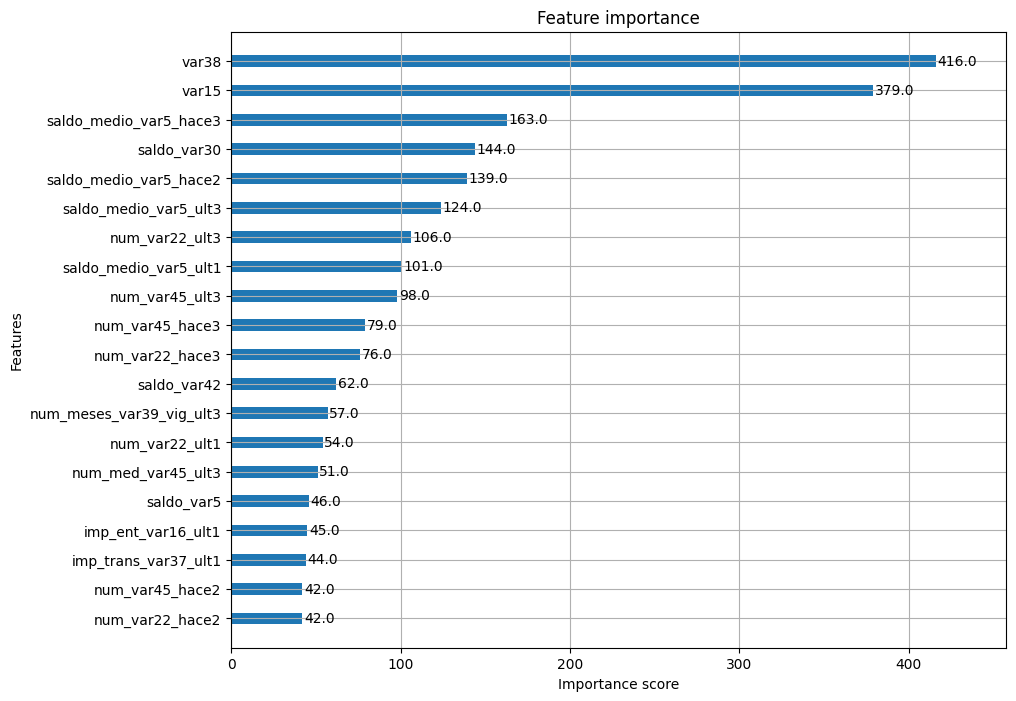

In [ ]:
from xgboost import plot_importance

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

plot_importance(xgb_clf, ax=ax,
                max_num_features=20, height=0.4)

plt.show()

## 11. LightGBM 모델 학습

이번에는 동일한 데이터에 LightGBM을 적용한다.

LightGBM은 일반적인 GBM보다 빠르게 학습할 수 있는 부스팅 알고리즘이다.
먼저 기본 모델을 학습하고 ROC-AUC를 측정한다.

In [ ]:
!pip install lightgbm -q

In [ ]:
from lightgbm import LGBMClassifier, early_stopping

lgbm_clf = LGBMClassifier(n_estimators=500)

eval_set = [(X_tr, y_tr), (X_val, y_val)]

lgbm_clf.fit(X_tr, y_tr,
             eval_metric='auc',
             eval_set=eval_set,
             callbacks=[early_stopping(100, verbose=False)])

lgbm_roc_score = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:, 1])

print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

ROC AUC: 0.8384


## 12. LightGBM 하이퍼파라미터 튜닝

LightGBM 역시 HyperOpt를 이용하여 하이퍼파라미터를 튜닝한다.

탐색할 파라미터는 다음과 같다.

- num_leaves: 하나의 트리가 가질 수 있는 최대 리프 수
- max_depth: 트리의 최대 깊이
- min_child_samples: 하나의 리프에 필요한 최소 데이터 수
- subsample: 학습에 사용할 데이터의 비율
- learning_rate: 학습률

XGBoost와 마찬가지로 3-Fold 교차 검증의 평균 ROC-AUC를 기준으로 최적의 조합을 찾는다.

In [ ]:
lgbm_search_space = {
    'num_leaves': hp.quniform('num_leaves', 32, 64, 1),
    'max_depth': hp.quniform('max_depth', 100, 160, 1),
    'min_child_samples': hp.quniform('min_child_samples', 60, 100, 1),
    'subsample': hp.uniform('subsample', 0.7, 1),
    'learning_rate': hp.uniform('learning_rate', 0.01, 0.2)
    }

In [ ]:
def objective_func_lgbm(search_space):

    lgbm_clf = LGBMClassifier(
        n_estimators=100,
        num_leaves=int(search_space['num_leaves']),
        max_depth=int(search_space['max_depth']),
        min_child_samples=int(search_space['min_child_samples']),
        subsample=search_space['subsample'],
        learning_rate=search_space['learning_rate'],
        verbose=-1
        )

    roc_auc_list = []

    kf = KFold(n_splits=3)

    for tr_index, val_index in kf.split(X_train):

        X_tr_cv = X_train.iloc[tr_index]
        y_tr_cv = y_train.iloc[tr_index]

        X_val_cv = X_train.iloc[val_index]
        y_val_cv = y_train.iloc[val_index]

        lgbm_clf.fit(X_tr_cv, y_tr_cv)

        score = roc_auc_score(y_val_cv,
            lgbm_clf.predict_proba(X_val_cv)[:, 1])

        roc_auc_list.append(score)

    return -1 * np.mean(roc_auc_list)

In [ ]:
trials = Trials()

best_lgbm = fmin(fn=objective_func_lgbm,
                 space=lgbm_search_space,
                 algo=tpe.suggest,
                 max_evals=50,
                 trials=trials,
                 rstate=np.random.default_rng(seed=30))

print('best:', best_lgbm)

100%|██████████| 50/50 [07:04<00:00,  8.50s/trial, best loss: -0.8360775036381334]
best: {'learning_rate': np.float64(0.035061433535000054), 'max_depth': np.float64(126.0), 'min_child_samples': np.float64(86.0), 'num_leaves': np.float64(33.0), 'subsample': np.float64(0.9093328147411339)}


## 13. 튜닝된 LightGBM 최종 평가

In [ ]:
lgbm_clf = LGBMClassifier(
    n_estimators=500,
    num_leaves=int(best_lgbm['num_leaves']),
    max_depth=int(best_lgbm['max_depth']),
    min_child_samples=int(best_lgbm['min_child_samples']),
    subsample=round(best_lgbm['subsample'], 5),
    learning_rate=round(best_lgbm['learning_rate'], 5)
    )

lgbm_clf.fit(X_tr, y_tr,
             eval_metric='auc',
             eval_set=[(X_tr, y_tr), (X_val, y_val)],
             callbacks=[early_stopping(100, verbose=False)])

lgbm_roc_score = roc_auc_score(y_test, lgbm_clf.predict_proba(X_test)[:, 1])

print('ROC AUC: {0:.4f}'.format(lgbm_roc_score))

ROC AUC: 0.8420


HyperOpt에서 찾은 하이퍼파라미터를 이용하여 LightGBM을 다시 학습하고 최종 ROC-AUC를 확인한다.

교재에서는 기본 LightGBM의 ROC-AUC가 약 0.8384였고, 튜닝 후 약 0.8446으로 향상되었다.

따라서 LightGBM에서도 적절한 하이퍼파라미터 튜닝을 통해 예측 성능을 높일 수 있음을 확인할 수 있다.

# 전체 프로세스 정리

이번 실습에서는 산탄데르 고객 데이터를 이용하여 고객 만족 여부를 예측하였다.

먼저 TARGET의 분포를 확인한 결과 불만족 고객이 약 4%로 데이터가 불균형하다는 것을 확인하였다.

이후 var3의 비정상적인 값인 -999999를 처리하고, 단순 식별자인 ID를 제거한 뒤 데이터를 학습용과 테스트용으로 분리하였다.

첫 번째 모델로 XGBoost를 사용하였다. 기본 모델의 성능을 ROC-AUC로 평가한 뒤 HyperOpt와 3-Fold 교차 검증을 이용하여 하이퍼파라미터를 탐색하였다. 이후 최적의 파라미터로 모델을 다시 학습하여 성능 변화를 확인하고, 피처 중요도를 통해 예측에 영향을 많이 준 피처도 확인하였다.

두 번째로 LightGBM을 사용하여 같은 과정을 반복하였다. 기본 모델을 학습한 뒤 HyperOpt를 이용해 주요 하이퍼파라미터를 튜닝하고 최종 ROC-AUC를 확인하였다.

전체적인 과정은 다음과 같다.

데이터 확인
→ 클래스 분포 확인
→ 이상값 및 불필요한 피처 처리
→ 학습/테스트 데이터 분리
→ 기본 모델 학습
→ ROC-AUC 평가
→ HyperOpt + 교차 검증을 이용한 하이퍼파라미터 탐색
→ 최적 파라미터로 재학습
→ 최종 성능 평가

이를 통해 단순히 모델을 한 번 학습하는 것이 아니라, 데이터의 특징을 먼저 확인하고 기본 모델의 성능을 측정한 뒤 하이퍼파라미터를 조정하여 성능을 개선하는 전체적인 머신러닝 분류 과정을 실습하였다.

# Decision Tree and Random Forest Classifier Models

## 실습 목표

Drug Classification 데이터셋을 이용하여 환자의 정보를 바탕으로 처방될 약물의 종류를 예측한다.

이번 실습에서는 다음과 같은 과정을 진행한다.

데이터 확인 및 시각화  
→ 범주형 데이터 변환  
→ 학습/테스트 데이터 분리  
→ Decision Tree 학습  
→ Gini와 Entropy 비교  
→ Random Forest 학습  
→ 파라미터에 따른 성능 비교  
→ 최종 모델 평가  
→ Confusion Matrix 확인

이를 통해 Decision Tree와 Random Forest의 분류 과정을 이해하고 두 모델의 성능을 확인한다.

## 1. 데이터 불러오기

먼저 데이터 분석과 시각화에 필요한 라이브러리를 불러온다.

데이터셋은 환자의 나이, 성별, 혈압, 콜레스테롤 수치, Na/K 비율과 처방된 약물의 종류를 포함하고 있다.

In [282]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
import warnings

warnings.filterwarnings('ignore')

data = pd.read_csv('/content/drug200.csv')

## 2. 데이터 확인

모델을 학습하기 전에 데이터의 구조와 각 피처의 특징을 확인한다.

데이터의 크기, 자료형, 통계값과 각 범주형 변수에 어떤 값들이 들어 있는지 살펴본다.

In [283]:
data.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY


In [284]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [285]:
data.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


In [286]:
data.columns

Index(['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug'], dtype='object')

### 범주형 데이터 확인

Sex, BP, Cholesterol, Drug에는 숫자가 아닌 문자열 형태의 값이 존재한다.

머신러닝 모델에 입력하기 전에 어떤 값들로 구성되어 있는지 확인하고 이후 숫자 형태로 변환한다.

In [287]:
print(data['Sex'].value_counts())
print()

print(data['BP'].value_counts())
print()

print(data['Cholesterol'].value_counts())
print()

print(data['Drug'].value_counts())

Sex
M    104
F     96
Name: count, dtype: int64

BP
HIGH      77
LOW       64
NORMAL    59
Name: count, dtype: int64

Cholesterol
HIGH      103
NORMAL     97
Name: count, dtype: int64

Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


## 3. 데이터 시각화

각 변수의 분포와 Drug와의 관계를 시각화를 통해 확인한다.

In [290]:
import plotly.io as pio
pio.renderers.default = "colab"

In [291]:
dataAge = data["Age"].value_counts(dropna=False)

npar_dataAge = np.array(dataAge)
x = list(npar_dataAge)
y = data.Age.value_counts().index

DataAge = {"Age": y, "Number": x}
DataAge = pd.DataFrame(DataAge)

fig = px.bar(DataAge, x="Age", y="Number")
fig.show()

성별

In [292]:
colors = ['gold', 'mediumturquoise']

fig = go.Figure(
    data=[go.Pie(
        labels=['M', 'F'],
        values=[
            (data['Sex'] == 'M').sum(),
            (data['Sex'] == 'F').sum()
        ]
    )]
)

fig.update_traces(
    hoverinfo='label+percent',
    textinfo='value',
    textfont_size=20,
    marker=dict(colors=colors,
                line=dict(color='#000000', width=2))
)

fig.show()

혈압

In [293]:
fig = px.bar(
    x=data['BP'].value_counts().index,
    y=data['BP'].value_counts().values,
    labels={'x': 'BP', 'y': 'Number'}
)

fig.show()

콜레스테롤

In [294]:
fig = px.bar(
    x=data['Cholesterol'].value_counts().index,
    y=data['Cholesterol'].value_counts().values,
    labels={'x': 'Cholesterol', 'y': 'Number'}
)

fig.show()

약물중독

In [295]:
drug_counts = data['Drug'].value_counts()

fig = go.Figure(
    data=[go.Pie(
        labels=drug_counts.index,
        values=drug_counts.values
    )]
)

fig.update_traces(
    hoverinfo='label+percent',
    textinfo='value',
    textfont_size=20
)

fig.show()

Age와 Na_to_K 관계

In [296]:
fig = px.scatter(
    data,
    x="Na_to_K",
    y="Age",
    color="Drug",
    size="Age",
    hover_data=["Na_to_K"]
)

fig.show()

시각화를 통해 각 변수의 분포를 확인할 수 있으며, 특히 Na_to_K와 Age에 따라 처방되는 Drug의 종류가 달라지는 경향을 확인할 수 있다.

이제 이러한 피처들을 이용하여 실제 Drug 종류를 예측하는 분류 모델을 학습한다.

## 4. 데이터 전처리

현재 Sex, BP, Cholesterol, Drug 등의 값이 문자열로 되어 있으므로 머신러닝 모델에서 사용할 수 있도록 숫자로 변환한다.

원본 실습과 동일하게 각 범주에 숫자를 직접 대응시켜 변환한다.

In [297]:
dataclass = pd.read_csv('/content/drug200.csv')

dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


성별

In [298]:
# F = 1
# M = 0

dataclass['Sex'] = [
    1 if i == "F" else 0
    for i in dataclass['Sex']
]

BP

In [299]:
# LOW = 2
# NORMAL = 1
# HIGH = 0

for i in range(len(dataclass)):
    if dataclass.loc[i, 'BP'] == "LOW":
        dataclass.loc[i, 'BP'] = 2
    elif dataclass.loc[i, 'BP'] == "NORMAL":
        dataclass.loc[i, 'BP'] = 1
    else:
        dataclass.loc[i, 'BP'] = 0

콜레스테롤

In [300]:
# HIGH = 1
# NORMAL = 0

dataclass['Cholesterol'] = [
    1 if i == "HIGH" else 0
    for i in dataclass['Cholesterol']
]

Drug

In [301]:
# DrugY = 4
# DrugX = 3
# DrugA = 2
# DrugC = 1
# DrugB = 0

drug_mapping = {
    'DrugY': 4,
    'drugY': 4,
    'DrugX': 3,
    'drugX': 3,
    'DrugA': 2,
    'drugA': 2,
    'DrugC': 1,
    'drugC': 1,
    'DrugB': 0,
    'drugB': 0
}

dataclass['Drug'] = dataclass['Drug'].map(drug_mapping)

In [302]:
print(dataclass['Drug'].unique())
print(dataclass['Drug'].isnull().sum())

[4 1 3 2 0]
0


In [303]:
dataclass = dataclass.astype({
    'BP': int,
    'Drug': int
})

dataclass.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    int64  
 2   BP           200 non-null    int64  
 3   Cholesterol  200 non-null    int64  
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    int64  
dtypes: float64(1), int64(5)
memory usage: 9.5 KB


## 5. 학습 데이터 준비

Drug는 모델이 예측해야 하는 정답이므로 y 데이터로 분리하고, 나머지 변수들은 예측에 사용할 피처이므로 X 데이터로 사용한다.

이후 전체 데이터의 70%를 학습 데이터, 30%를 테스트 데이터로 분리한다.

In [304]:
x_data = dataclass.drop(["Drug"], axis=1)
y_data = dataclass["Drug"].values

In [305]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x_data,
    y_data,
    test_size=0.3,
    random_state=1
)

print('Train shape:', x_train.shape)
print('Test shape:', x_test.shape)

Train shape: (140, 5)
Test shape: (60, 5)


## 6. Decision Tree Classifier

Decision Tree는 여러 조건을 기준으로 데이터를 계속 나누어 최종적으로 클래스를 예측하는 모델이다.

트리의 중간 노드에서는 어떤 피처를 기준으로 데이터를 나눌지 결정하고, 마지막 리프 노드에서 최종 예측 결과가 결정된다.

먼저 별도의 파라미터를 지정하지 않은 기본 Decision Tree 모델을 학습한다.

In [306]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

dtc = DecisionTreeClassifier()

dtc.fit(x_train, y_train)

predict = dtc.predict(x_test)

print(
    'The accuracy of the Decision Tree is',
    metrics.accuracy_score(y_test, predict)
)

The accuracy of the Decision Tree is 0.9666666666666667


### Decision Tree - Gini

Decision Tree가 데이터를 나눌 기준으로 Gini를 사용한다.

Gini 값은 한 노드 안에 서로 다른 클래스가 얼마나 섞여 있는지를 나타내며, 값이 작을수록 특정 클래스가 잘 구분되어 있다는 의미이다.

max_depth=3으로 설정하여 트리가 지나치게 깊어지는 것을 제한한다.

In [307]:
from sklearn.metrics import accuracy_score

DTC_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=0
)

DTC_gini.fit(x_train, y_train)

y_pred_gini = DTC_gini.predict(x_test)

print(
    'Model accuracy score with criterion gini index: {0:0.4f}'
    .format(accuracy_score(y_test, y_pred_gini))
)

Model accuracy score with criterion gini index: 0.9000


* Train/Test 비교

In [308]:
y_pred_train_gini = DTC_gini.predict(x_train)

print(
    'Training-set accuracy score: {0:0.4f}'
    .format(accuracy_score(y_train, y_pred_train_gini))
)

print('Training set score: {:.4f}'.format(
    DTC_gini.score(x_train, y_train)
))

print('Test set score: {:.4f}'.format(
    DTC_gini.score(x_test, y_test)
))

Training-set accuracy score: 0.9143
Training set score: 0.9143
Test set score: 0.9000


학습 데이터와 테스트 데이터의 정확도를 함께 확인하면 모델이 학습 데이터에만 지나치게 맞춰진 과적합이 발생했는지 확인할 수 있다.

### Decision Tree - Entropy

이번에는 데이터를 나누는 기준으로 Entropy를 사용한다.

Entropy 역시 노드 안의 데이터가 얼마나 섞여 있는지를 나타내는 기준이다.

Gini를 사용했을 때와 Entropy를 사용했을 때의 정확도를 비교한다.

In [309]:
DTC_en = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=3,
    random_state=0
)

DTC_en.fit(x_train, y_train)

y_pred_en = DTC_en.predict(x_test)

print(
    'Model accuracy score with criterion entropy: {0:0.4f}'
    .format(accuracy_score(y_test, y_pred_en))
)

Model accuracy score with criterion entropy: 0.9000


In [310]:
y_pred_train_en = DTC_en.predict(x_train)

print(
    'Training-set accuracy score: {0:0.4f}'
    .format(accuracy_score(y_train, y_pred_train_en))
)

print('Training set score: {:.4f}'.format(
    DTC_en.score(x_train, y_train)
))

print('Test set score: {:.4f}'.format(
    DTC_en.score(x_test, y_test)
))

Training-set accuracy score: 0.9143
Training set score: 0.9143
Test set score: 0.9000


## 7. Random Forest Classifier

Random Forest는 하나의 Decision Tree만 사용하는 대신 여러 개의 Decision Tree를 만들어 그 결과를 종합하여 최종 예측을 수행한다.

하나의 트리에만 의존하지 않기 때문에 일반적으로 Decision Tree보다 과적합을 줄이고 안정적인 예측을 할 수 있다.

In [311]:
from sklearn.ensemble import RandomForestClassifier

rfc = RandomForestClassifier(random_state=0)

rfc.fit(x_train, y_train)

predict = rfc.predict(x_test)

print(
    'The accuracy of the Random Forest is',
    metrics.accuracy_score(y_test, predict)
)

The accuracy of the Random Forest is 0.95


### n_estimators 설정

n_estimators는 Random Forest에서 생성할 Decision Tree의 개수를 의미한다.

여기서는 100개의 트리를 생성하여 Random Forest를 학습한다.

In [312]:
rfc_100 = RandomForestClassifier(
    n_estimators=100,
    random_state=0
)

rfc_100.fit(x_train, y_train)

predict = rfc_100.predict(x_test)

print(
    'The accuracy of the Random Forest is',
    metrics.accuracy_score(y_test, predict)
)

The accuracy of the Random Forest is 0.95


### 파라미터에 따른 성능 비교

Random Forest의 설정값에 따라 학습 데이터와 테스트 데이터의 정확도가 어떻게 달라지는지 확인한다.

먼저 random_state 값을 변화시키면서 정확도를 비교하고, 이후 n_estimators 값을 변화시키면서 성능을 확인한다.

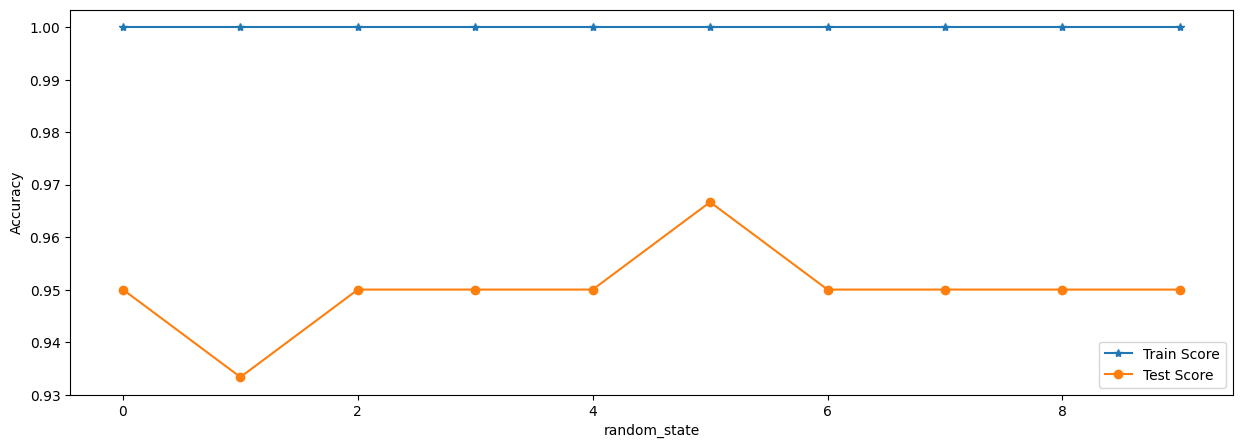

In [313]:
test_score_list = []
train_score_list = []

for i in range(10):
    rfc2 = RandomForestClassifier(random_state=i)

    rfc2.fit(x_train, y_train)

    test_score_list.append(rfc2.score(x_test, y_test))
    train_score_list.append(rfc2.score(x_train, y_train))

plt.figure(figsize=(15,5))

plt.plot(
    range(10),
    train_score_list,
    marker='*',
    label='Train Score'
)

plt.plot(
    range(10),
    test_score_list,
    marker='o',
    label='Test Score'
)

plt.xlabel('random_state')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

* n_estimators 비교

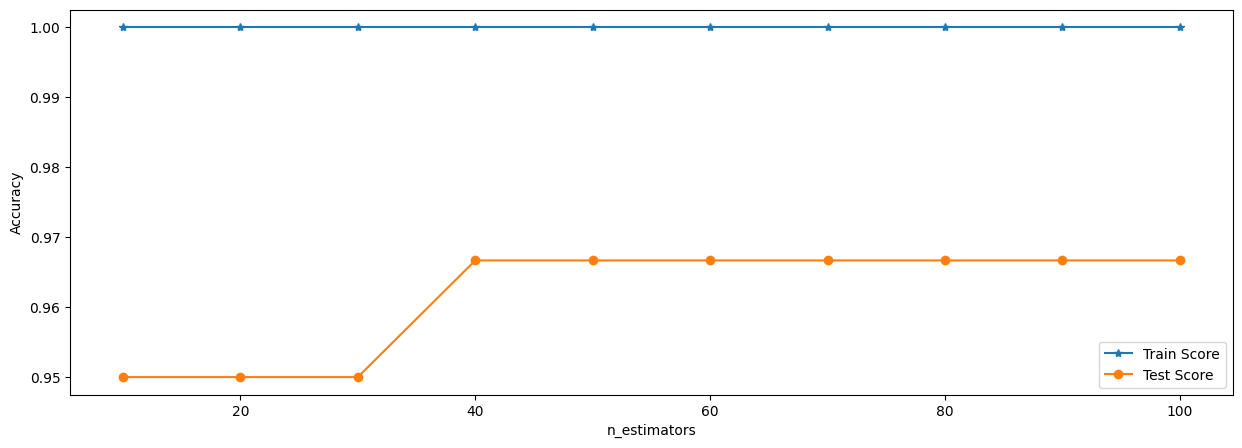

In [314]:
test_score_list = []
train_score_list = []

list_n_estimators = [
    10, 20, 30, 40, 50,
    60, 70, 80, 90, 100
]

for n in list_n_estimators:

    rfc3 = RandomForestClassifier(
        n_estimators=n,
        random_state=5
    )

    rfc3.fit(x_train, y_train)

    test_score_list.append(
        rfc3.score(x_test, y_test)
    )

    train_score_list.append(
        rfc3.score(x_train, y_train)
    )

plt.figure(figsize=(15,5))

plt.plot(
    list_n_estimators,
    train_score_list,
    marker='*',
    label='Train Score'
)

plt.plot(
    list_n_estimators,
    test_score_list,
    marker='o',
    label='Test Score'
)

plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

n_estimators를 변화시키면서 Random Forest를 구성하는 트리의 개수에 따른 정확도 변화를 확인하였다.

원본 실습에서는 random_state=5, n_estimators=100을 이용하여 최종 Random Forest 모델을 생성한다.

## 최종 Random Forest

In [315]:
last_rfc = RandomForestClassifier(
    n_estimators=100,
    random_state=5
)

last_rfc.fit(x_train, y_train)

predict = last_rfc.predict(x_test)

print(
    'The accuracy of the Random Forest is',
    metrics.accuracy_score(y_test, predict)
)

print(
    'Training set score: {:.4f}'
    .format(last_rfc.score(x_train, y_train))
)

print(
    'Test set score: {:.4f}'
    .format(last_rfc.score(x_test, y_test))
)

The accuracy of the Random Forest is 0.9666666666666667
Training set score: 1.0000
Test set score: 0.9667


## 8. Confusion Matrix를 이용한 모델 평가

정확도만으로는 모델이 각 클래스를 어떻게 예측했는지 자세히 알기 어렵다.

Confusion Matrix는 실제 클래스와 모델이 예측한 클래스를 비교하여 어떤 클래스를 정확하게 예측했고 어떤 클래스를 잘못 예측했는지 확인할 수 있게 해준다.

이번 데이터는 Drug가 여러 종류이므로 각 약물 클래스별 실제값과 예측값의 관계를 행렬로 확인한다.

* 기본 Decision Tree

In [316]:
from sklearn.metrics import confusion_matrix

cm_des = DecisionTreeClassifier()

cm_des.fit(x_train, y_train)

y_pred_cm = cm_des.predict(x_test)

cm_des1 = confusion_matrix(y_test, y_pred_cm)

cm_des1

array([[ 4,  0,  2,  0,  0],
       [ 0,  4,  0,  0,  0],
       [ 0,  0,  4,  0,  0],
       [ 0,  0,  0, 19,  0],
       [ 0,  0,  0,  0, 27]])

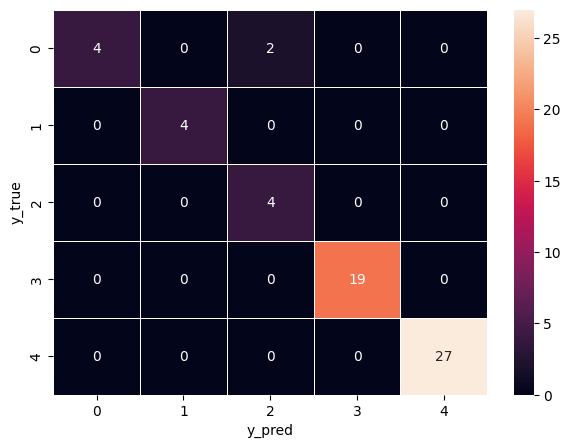

In [317]:
plt.figure(figsize=(7,5))

sns.heatmap(
    cm_des1,
    annot=True,
    linewidths=0.5,
    fmt=".0f"
)

plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

* Gini Decision Tree

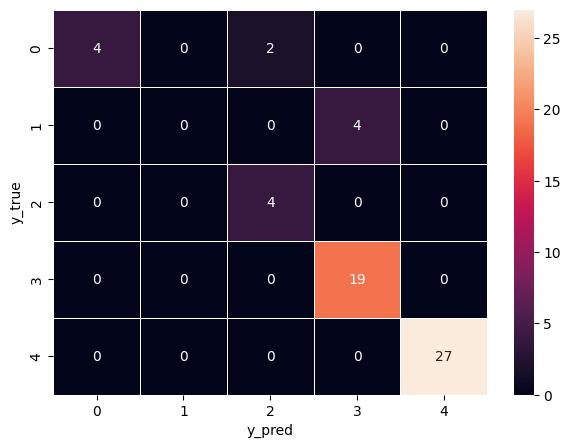

In [318]:
cm_des_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=3,
    random_state=0
)

cm_des_gini.fit(x_train, y_train)

y_pred_cm = cm_des_gini.predict(x_test)

cm_des2 = confusion_matrix(
    y_test,
    y_pred_cm
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_des2,
    annot=True,
    linewidths=0.5,
    fmt=".0f"
)

plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

* 최종 Random Forest

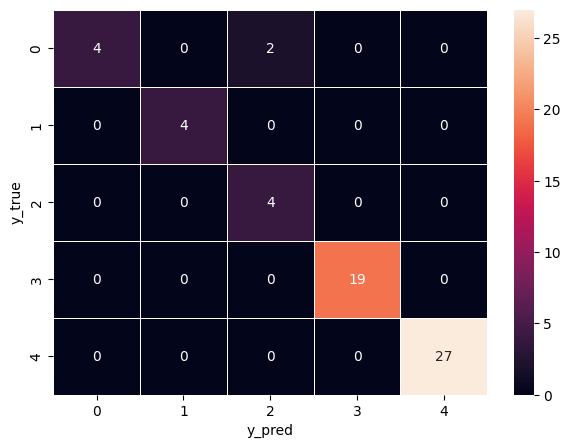

In [319]:
cm_last_rfc = RandomForestClassifier(
    n_estimators=100,
    random_state=5
)

cm_last_rfc.fit(x_train, y_train)

y_pred_cm = cm_last_rfc.predict(x_test)

cm_rfc = confusion_matrix(
    y_test,
    y_pred_cm
)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm_rfc,
    annot=True,
    linewidths=0.5,
    fmt=".0f"
)

plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

# 전체 프로세스 정리

이번 실습에서는 환자의 정보를 이용하여 처방될 Drug의 종류를 예측하는 다중 분류 문제를 수행하였다.

먼저 데이터의 구조와 각 변수의 분포를 확인하고 시각화를 통해 데이터의 특징을 살펴보았다.

이후 머신러닝 모델에서 사용할 수 있도록 Sex, BP, Cholesterol과 같은 범주형 데이터를 숫자로 변환하였다. Drug를 예측해야 할 정답 데이터로 분리하고 나머지 변수들을 피처로 사용한 뒤, 데이터를 학습용과 테스트용으로 나누었다.

첫 번째 모델로 Decision Tree를 사용하였다. 기본 모델을 학습한 뒤 데이터를 나누는 기준으로 Gini와 Entropy를 각각 적용하고 학습 데이터와 테스트 데이터의 정확도를 비교하였다.

두 번째 모델로 Random Forest를 사용하였다. Random Forest는 여러 개의 Decision Tree의 결과를 종합하여 예측하는 모델이며, n_estimators 값을 변화시키면서 트리 개수에 따른 성능 변화를 확인하였다.

마지막으로 Confusion Matrix를 이용하여 실제 Drug와 모델이 예측한 Drug를 비교하였다.

전체 과정은 다음과 같다.

데이터 확인 및 시각화  
→ 범주형 데이터 숫자 변환  
→ X와 y 분리  
→ 학습/테스트 데이터 분리  
→ Decision Tree 학습  
→ Gini와 Entropy 비교  
→ Random Forest 학습  
→ 파라미터에 따른 성능 비교  
→ 최종 모델 학습  
→ Confusion Matrix를 이용한 평가

이를 통해 데이터를 머신러닝에 사용할 수 있는 형태로 전처리한 뒤 Decision Tree와 Random Forest를 이용하여 분류하고, 모델의 성능을 평가하는 전체적인 분류 과정을 실습하였다.

# **Heart Failure Prediction - CatBoost with Optuna**

## 실습 목표

이 실습에서는 환자의 여러 정보를 이용하여 심장 질환(HeartDisease) 여부를 예측하는 분류 모델을 만든다.

먼저 데이터를 확인하고 EDA를 진행한 뒤 여러 머신러닝 모델의 성능을 비교한다.
이후 CatBoost 모델을 적용하고, Optuna를 이용하여 CatBoost의 하이퍼파라미터를 조정한다.

### 전체 진행 과정

1. 데이터 확인 및 EDA
2. 타깃 변수와 수치형/범주형 변수 분석
3. 여러 분류 모델의 성능 비교
4. CatBoost 모델 학습
5. Optuna를 이용한 CatBoost 하이퍼파라미터 튜닝
6. Feature Importance 확인
7. 모델 성능 비교

## 데이터 설명

사용하는 데이터는 Heart Failure Prediction Dataset이다.

- Age : 나이
- Sex : 성별
- ChestPainType : 흉통 유형
- RestingBP : 안정 시 혈압
- Cholesterol : 콜레스테롤 수치
- FastingBS : 공복 혈당
- RestingECG : 안정 시 심전도 결과
- MaxHR : 최대 심박수
- ExerciseAngina : 운동으로 인한 협심증 여부
- Oldpeak : ST depression 값
- ST_Slope : 운동 시 ST segment의 기울기
- HeartDisease : 심장 질환 여부 (1: 심장 질환, 0: 정상)

이 중 HeartDisease가 예측하고자 하는 타깃 변수이다.

## 문제 정의 및 평가 지표

HeartDisease 값이 0 또는 1이므로 이 문제는 분류(Classification) 문제이다.

환자의 여러 특성을 이용하여 HeartDisease를 최대한 정확하게 분류하는 것이 목표이다.

먼저 타깃 변수의 분포를 확인하고, 클래스가 크게 불균형하지 않다면 모델의 평가 지표로 Accuracy를 사용한다.

In [ ]:
!pip install catboost optuna

In [ ]:
!pip install catboost optuna cufflinks

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import (
    KFold, cross_val_score, RepeatedStratifiedKFold,
    StratifiedKFold, cross_val_predict,
    train_test_split, GridSearchCV
)

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PowerTransformer
from sklearn.compose import ColumnTransformer, make_column_transformer

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    ExtraTreesClassifier
)

from sklearn.metrics import accuracy_score, classification_report

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import optuna


import plotly
import plotly.express as px
import plotly.graph_objs as go
import plotly.offline as py
from plotly.offline import iplot
from plotly.subplots import make_subplots
import plotly.figure_factory as ff

import cufflinks as cf

cf.go_offline()
cf.set_config_file(offline=False, world_readable=True)

* 데이터 불러오기

In [ ]:
df = pd.read_csv('/content/heart.csv')

In [ ]:
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 900)
pd.set_option('display.max_colwidth', 200)

df = pd.read_csv('/content/heart.csv')

df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


* 데이터 기본 정보 확인

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


### 데이터 기본 정보 확인

`info()`를 이용하면 데이터의 행과 열 개수, 각 열의 자료형, 결측치 여부 등을 확인할 수 있다.

모델을 만들기 전에 데이터가 어떤 형태로 구성되어 있는지 먼저 확인하는 과정이다.

* 중복 데이터 확인

In [ ]:
df.duplicated().sum()

np.int64(0)

### 중복 데이터 확인

`duplicated().sum()`을 이용하여 동일한 데이터가 중복되어 있는지 확인한다.

결과가 0이므로 중복 데이터는 존재하지 않는다.

* 결측치 확인

In [ ]:
def missing(df):
    missing_number = df.isnull().sum().sort_values(ascending=False)

    missing_percent = (
        df.isnull().sum() / df.isnull().count()
    ).sort_values(ascending=False)

    missing_values = pd.concat(
        [missing_number, missing_percent],
        axis=1,
        keys=['Missing_Number', 'Missing_Percent']
    )

    return missing_values

missing(df)

,Missing_Number,Missing_Percent
Age,0,0.0
Sex,0,0.0
ChestPainType,0,0.0
RestingBP,0,0.0
Cholesterol,0,0.0
FastingBS,0,0.0
RestingECG,0,0.0
MaxHR,0,0.0
ExerciseAngina,0,0.0
Oldpeak,0,0.0


### 결측치 확인

머신러닝 모델을 학습하기 전에 데이터에 비어 있는 값이 존재하는지 확인해야 한다.

- Missing_Number : 각 변수의 결측치 개수
- Missing_Percent : 각 변수에서 결측치가 차지하는 비율

이 데이터에서는 결측치가 존재하지 않는다.

* 수치형 / 범주형 변수 구분

In [ ]:
numerical = df.drop(['HeartDisease'], axis=1).select_dtypes('number').columns

categorical = df.select_dtypes('object').columns

print(f'Numerical Columns: {df[numerical].columns}')
print('\n')
print(f'Categorical Columns: {df[categorical].columns}')

Numerical Columns: Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak'], dtype='object')


Categorical Columns: Index(['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope'], dtype='object')


### 수치형 변수와 범주형 변수

변수의 종류에 따라 전처리 방법이나 분석 방법이 달라질 수 있기 때문에 수치형 변수와 범주형 변수를 구분한다.

- Numerical : 숫자로 표현되는 수치형 변수
- Categorical : 여러 범주로 나누어지는 범주형 변수

HeartDisease는 예측해야 하는 타깃 변수이므로 numerical 변수 목록에서는 제외하였다.

In [ ]:
df[categorical].nunique()

,0
Sex,2
ChestPainType,4
RestingECG,3
ExerciseAngina,2
ST_Slope,3


각 범주형 변수에 몇 개의 서로 다른 값이 존재하는지 확인한다.

이를 통해 범주형 변수의 종류가 지나치게 많지는 않은지 확인할 수 있다.

* 타깃 변수 확인

In [ ]:
y = df['HeartDisease']

print(
    f'Percentage of patient had a HeartDisease: '
    f'{round(y.value_counts(normalize=True)[1] * 100, 2)} % '
    f'--> ({y.value_counts()[1]} patient)\n'

    f'Percentage of patient did not have a HeartDisease: '
    f'{round(y.value_counts(normalize=True)[0] * 100, 2)} % '
    f'--> ({y.value_counts()[0]} patient)'
)

Percentage of patient had a HeartDisease: 55.34 % --> (508 patient)
Percentage of patient did not have a HeartDisease: 44.66 % --> (410 patient)


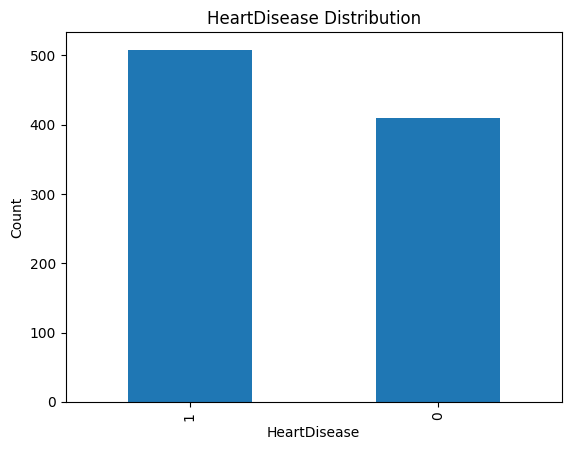

In [ ]:
df['HeartDisease'].value_counts().plot(kind='bar')

plt.title('HeartDisease Distribution')
plt.xlabel('HeartDisease')
plt.ylabel('Count')
plt.show()

### 타깃 변수 분포 확인

HeartDisease의 분포를 확인한 결과 심장 질환이 있는 환자는 약 55%, 없는 환자는 약 45%이다.

두 클래스의 비율에 약간의 차이는 있지만 한쪽 클래스에 데이터가 지나치게 몰려 있지는 않다.

따라서 이 실습에서는 Accuracy를 주요 평가 지표로 사용한다.

## Numerical Features Analysis

이제 수치형 변수들이 HeartDisease와 어떤 관계를 가지는지 확인한다.

수치형 변수의 분포를 살펴보고, 심장 질환이 있는 경우와 없는 경우에 각 변수의 분포가 어떻게 다른지 비교한다.

In [ ]:
df[numerical].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2


### 수치형 변수의 기초 통계량 확인

`describe()`를 이용하면 각 수치형 변수의 평균, 표준편차, 최솟값, 최댓값 등을 확인할 수 있다.

이를 통해 각 변수의 전체적인 분포와 값의 범위를 파악할 수 있다.

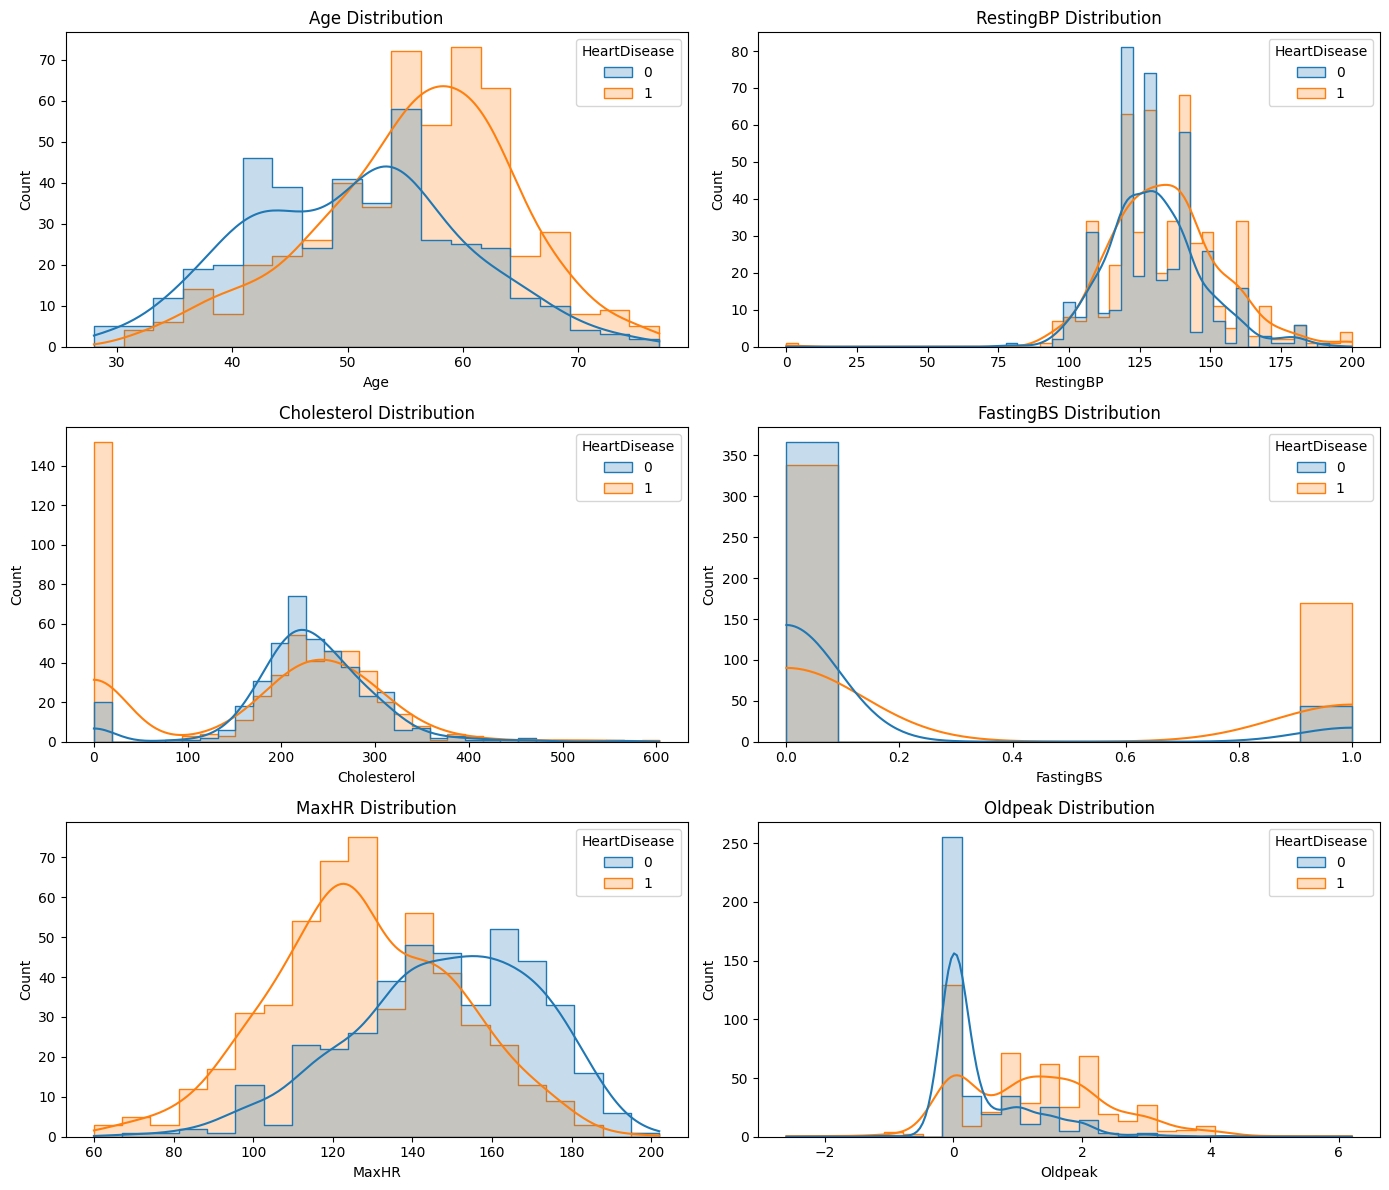

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes = axes.flatten()

for i, col in enumerate(numerical):
    sns.histplot(data=df, x=col, hue='HeartDisease',
                 kde=True, ax=axes[i], element='step')
    axes[i].set_title(f'{col} Distribution')

plt.tight_layout()
plt.show()

### 수치형 변수와 HeartDisease의 관계

각 수치형 변수의 분포를 HeartDisease가 0인 경우와 1인 경우로 나누어 비교한다.

그래프를 통해 특정 변수의 값이 달라질 때 심장 질환 여부의 분포도 달라지는지 확인할 수 있다.

예를 들어 Age, MaxHR, Oldpeak 등은 HeartDisease 여부에 따라 분포에 차이가 나타나는 것을 확인할 수 있다.

## Categorical Features Analysis

이번에는 범주형 변수와 HeartDisease의 관계를 확인한다.

각 범주에 포함된 데이터의 수를 확인하고, 범주에 따라 심장 질환 여부가 어떻게 달라지는지 살펴본다.

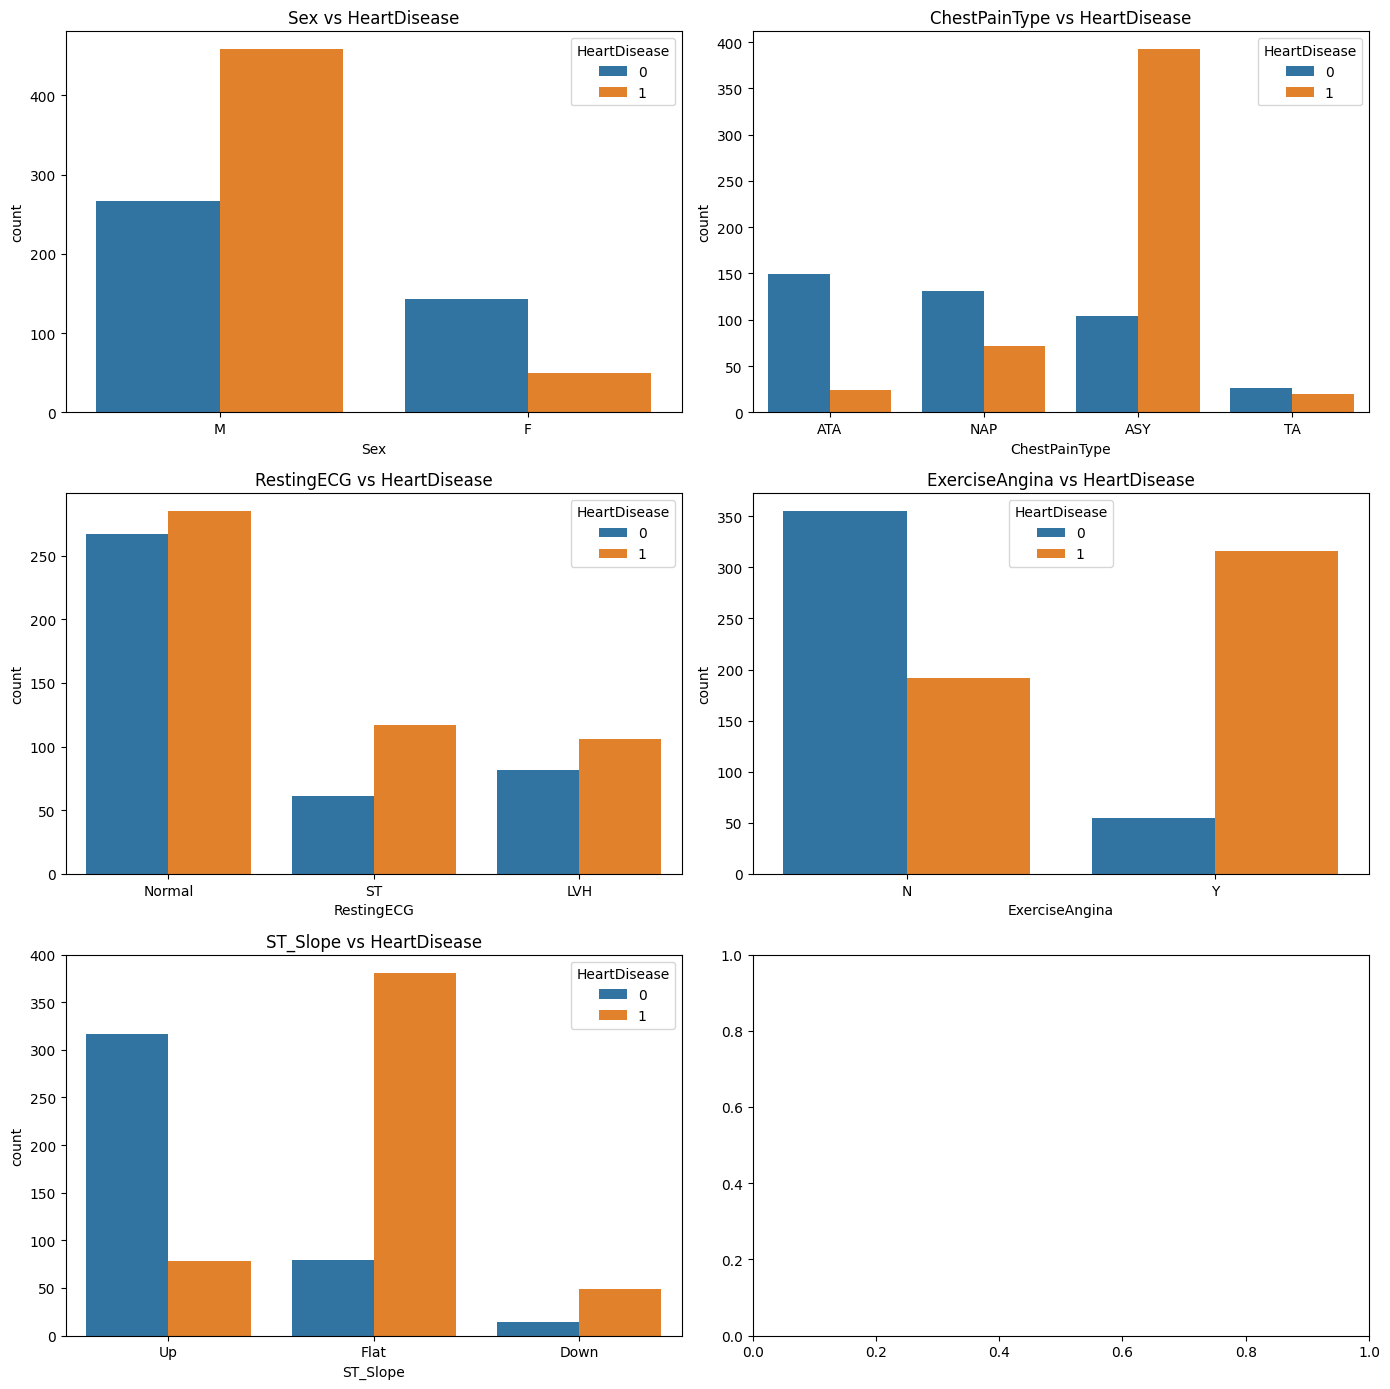

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

axes = axes.flatten()

for i, col in enumerate(categorical):
    sns.countplot(data=df, x=col, hue='HeartDisease', ax=axes[i])
    axes[i].set_title(f'{col} vs HeartDisease')

plt.tight_layout()
plt.show()

### 범주형 변수와 HeartDisease의 관계

범주형 변수의 각 범주별로 HeartDisease의 분포를 비교하였다.

Sex, ChestPainType, ExerciseAngina, ST_Slope 등에서 범주에 따라 HeartDisease의 비율이 달라지는 것을 확인할 수 있다.

따라서 이러한 변수들도 심장 질환을 예측하는 데 유용한 정보가 될 수 있다.

## Modeling

EDA를 통해 데이터의 특징을 확인했으므로 모델 학습을 위한 데이터를 준비한다.

HeartDisease는 예측해야 하는 타깃 변수이므로 y로 분리하고, 나머지 변수들은 모델이 학습할 피처 X로 사용한다.

In [ ]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

print(X.shape)
print(y.shape)

(918, 11)
(918,)


- X : 모델에게 주는 문제, 즉 환자의 여러 특성
- y : 모델이 맞혀야 하는 정답인 HeartDisease

따라서 모델은 X의 패턴을 학습하여 새로운 환자의 HeartDisease 값을 예측하게 된다.

In [ ]:
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()
categorical_cols = X.select_dtypes(include='object').columns.tolist()

print('Numerical:', numerical_cols)
print('Categorical:', categorical_cols)

Numerical: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


모델에 데이터를 입력하기 전에 수치형 변수와 범주형 변수를 구분한다.

일반적인 머신러닝 모델에서는 범주형 데이터를 숫자로 변환하는 전처리가 필요하기 때문에 두 종류의 변수를 따로 구분해 둔다.

In [ ]:
numerical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

## 데이터 전처리

수치형 변수와 범주형 변수는 서로 다른 방식으로 전처리한다.

### 수치형 변수
- 결측치가 있다면 중앙값으로 채운다.
- StandardScaler를 이용하여 변수들의 스케일을 맞춘다.

### 범주형 변수
- 결측치가 있다면 가장 자주 등장하는 값으로 채운다.
- One-Hot Encoding을 이용하여 문자 형태의 범주를 모델이 사용할 수 있는 숫자 형태로 변환한다.

ColumnTransformer를 이용하면 수치형 변수와 범주형 변수에 서로 다른 전처리를 한 번에 적용할 수 있다.

## 여러 분류 모델 비교

CatBoost를 적용하기 전에 여러 기본 분류 모델의 성능을 비교한다.

동일한 데이터와 평가 방법을 사용하여 여러 모델의 Accuracy를 비교하면 어떤 모델이 이 데이터에서 비교적 좋은 성능을 보이는지 확인할 수 있다.

In [ ]:
models = {
    'Dummy': DummyClassifier(strategy='most_frequent'),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'SVC': SVC(),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Extra Trees': ExtraTreesClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(random_state=42)
}

In [ ]:
results = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():

    pipeline = Pipeline(
        steps=[
            ('preprocessor', preprocessor),
            ('model', model)
        ]
    )

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring='accuracy'
    )

    results.append({
        'Model': name,
        'Accuracy': scores.mean()
    })

results_df = pd.DataFrame(results).sort_values(
    by='Accuracy',
    ascending=False
)

results_df

,Model,Accuracy
1,Logistic Regression,0.867100
3,SVC,0.866019
4,Random Forest,0.864909
6,Gradient Boosting,0.863828
2,KNN,0.859480
7,AdaBoost,0.859474
5,Extra Trees,0.850731
0,Dummy,0.553374


### 교차 검증을 이용한 모델 비교

각 모델의 성능을 한 번의 데이터 분할만으로 판단하지 않고 교차 검증을 이용하여 비교한다.

StratifiedKFold는 각 Fold에서 클래스의 비율이 비슷하게 유지되도록 데이터를 나누는 방법이다.

각 모델의 Accuracy를 여러 Fold에서 계산한 뒤 평균을 내어 모델의 성능을 비교한다.

In [ ]:
scores.mean()

np.float64(0.8594737467331907)

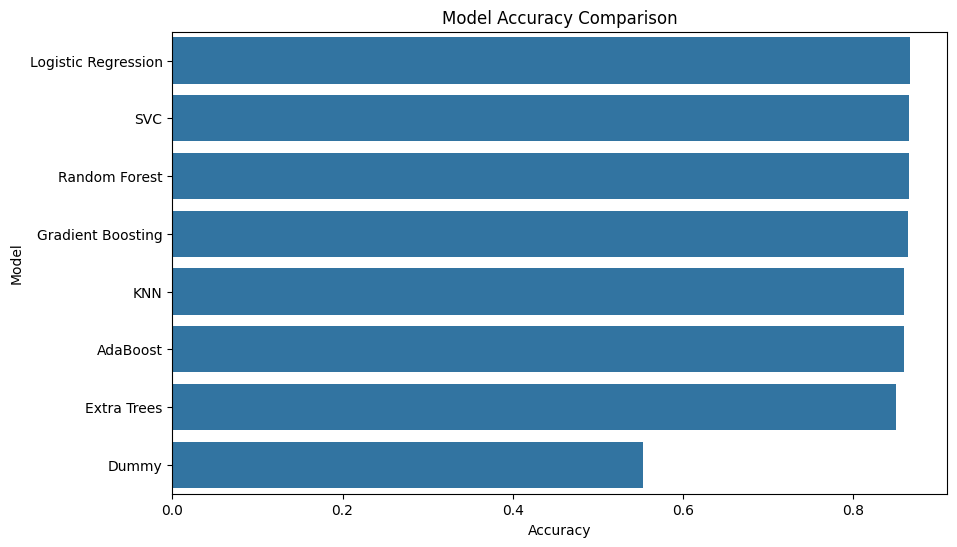

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x='Accuracy',
    y='Model'
)

plt.title('Model Accuracy Comparison')
plt.show()

여러 분류 모델의 교차 검증 Accuracy를 비교하였다.

모델에 따라 성능에 차이가 있으며, 이후에는 범주형 데이터를 효과적으로 처리할 수 있는 부스팅 모델인 CatBoost를 적용하여 성능을 확인한다.

## CatBoost

이제 CatBoost 모델을 이용하여 HeartDisease를 예측한다.

CatBoost는 Gradient Boosting 계열의 알고리즘으로, 범주형 변수를 직접 처리할 수 있다는 특징이 있다.

따라서 앞의 일반적인 머신러닝 모델처럼 범주형 변수를 One-Hot Encoding한 뒤 학습시키지 않고, 어떤 변수가 범주형 변수인지 CatBoost에 직접 알려주어 학습할 수 있다.

In [ ]:
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

cat_features = X.select_dtypes(include='object').columns.tolist()

print('Categorical Features:', cat_features)

Categorical Features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


`cat_features`에는 CatBoost가 범주형 변수로 처리해야 하는 열의 이름을 저장한다.

이를 이용하면 CatBoost가 Sex, ChestPainType 등의 범주형 변수를 직접 처리하면서 모델을 학습할 수 있다.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test:', X_test.shape)

X_train: (734, 11)
X_test: (184, 11)


전체 데이터를 학습 데이터와 테스트 데이터로 분리한다.

학습 데이터는 모델을 학습하는 데 사용하고, 테스트 데이터는 학습이 끝난 모델의 최종 성능을 확인하는 데 사용한다.

`stratify=y`를 사용하여 학습 데이터와 테스트 데이터에서도 HeartDisease의 0과 1 비율이 비슷하게 유지되도록 한다.

## 기본 CatBoost 모델

먼저 별도의 하이퍼파라미터 튜닝을 하지 않은 CatBoost 모델을 학습하여 기본 성능을 확인한다.

이후 Optuna로 하이퍼파라미터를 조정한 모델과 성능을 비교한다.

In [ ]:
cat_model = CatBoostClassifier(
    random_state=42,
    verbose=0
)

cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

cat_pred = cat_model.predict(X_test)

cat_accuracy = accuracy_score(y_test, cat_pred)

print('CatBoost Accuracy:', cat_accuracy)

CatBoost Accuracy: 0.8913043478260869


기본 CatBoost 모델의 Accuracy를 측정하였다.

이 값은 이후 Optuna로 하이퍼파라미터를 튜닝한 모델의 성능과 비교하기 위한 기준이 된다.

In [ ]:
print(classification_report(y_test, cat_pred))

              precision    recall  f1-score   support

           0       0.90      0.85      0.88        82
           1       0.89      0.92      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184



`classification_report`를 이용하여 Accuracy뿐만 아니라 Precision, Recall, F1-score 등의 평가 지표도 확인한다.

이를 통해 모델이 HeartDisease의 각 클래스를 어느 정도 잘 분류했는지 자세히 확인할 수 있다.

# CatBoost with Optuna

기본 CatBoost 모델을 확인했으므로 이번에는 Optuna를 이용하여 하이퍼파라미터를 튜닝한다.

하이퍼파라미터는 모델이 직접 학습하는 값이 아니라 모델을 학습하기 전에 사용자가 설정해야 하는 값이다.

Optuna는 여러 하이퍼파라미터 조합을 직접 하나씩 지정하지 않아도 이전 시행의 결과를 참고하면서 좋은 성능을 낼 가능성이 높은 조합을 탐색한다.

In [ ]:
def objective(trial):

    params = {
        'iterations': trial.suggest_int('iterations', 100, 1000),
        'depth': trial.suggest_int('depth', 4, 10),
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.01, 0.3, log=True
        ),
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg', 1, 10
        ),
        'random_strength': trial.suggest_float(
            'random_strength', 0, 10
        ),
        'random_state': 42,
        'verbose': 0
    }

    model = CatBoostClassifier(**params)

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(
            n_splits=5,
            shuffle=True,
            random_state=42
        ),
        scoring='accuracy',
        params={
            'cat_features': cat_features
        }
    )

    return scores.mean()

## Optuna의 Objective Function

`objective()`는 Optuna가 한 번의 trial에서 어떤 하이퍼파라미터를 사용하고, 그 결과가 얼마나 좋은지를 계산하는 함수이다.

Optuna는 각 trial마다 하이퍼파라미터 값을 선택하고 CatBoost 모델을 학습한 뒤 교차 검증 Accuracy의 평균을 반환받는다.

여기서는 다음과 같은 값을 탐색한다.

- iterations : 반복 학습 횟수
- depth : 트리의 깊이
- learning_rate : 한 번의 학습에서 반영하는 정도
- l2_leaf_reg : 과적합을 줄이기 위한 규제 정도
- random_strength : 트리 분할에 무작위성을 추가하는 정도

Accuracy는 클수록 좋은 값이므로 Optuna가 이 값을 최대화하도록 설정한다.

In [ ]:
study = optuna.create_study(
    direction='maximize'
)

study.optimize(
    objective,
    n_trials=50
)

[I 2026-10-05 10:43:21,653] A new study created in memory with name: no-name-681deec1-14c9-4263-8965-df38cdf8bc53
[I 2026-10-05 10:43:50,641] Trial 0 finished with value: 0.8719690615972416 and parameters: {'iterations': 907, 'depth': 7, 'learning_rate': 0.010957138770463584, 'l2_leaf_reg': 4.83382552181525, 'random_strength': 1.1137178339648557}. Best is trial 0 with value: 0.8719690615972416.
[I 2026-10-05 10:44:12,634] Trial 1 finished with value: 0.8583729382163824 and parameters: {'iterations': 348, 'depth': 9, 'learning_rate': 0.021113023997595005, 'l2_leaf_reg': 5.451460312972041, 'random_strength': 0.056288313742817175}. Best is trial 0 with value: 0.8719690615972416.
[I 2026-10-05 10:44:29,481] Trial 2 finished with value: 0.8597055260460349 and parameters: {'iterations': 384, 'depth': 9, 'learning_rate': 0.017962481823037738, 'l2_leaf_reg': 6.8847069168450785, 'random_strength': 2.581149673820904}. Best is trial 0 with value: 0.8719690615972416.
[I 2026-10-05 10:45:28,760] Tr

`create_study()`를 이용하여 Optuna의 최적화 작업을 생성한다.

Accuracy는 값이 클수록 좋은 평가 지표이므로 `direction='maximize'`로 설정한다.

`n_trials=50`은 서로 다른 하이퍼파라미터 조합을 총 50번 시도한다는 의미이다.

In [ ]:
print('Best Accuracy:', study.best_value)
print('Best Parameters:')

study.best_params

Optuna 탐색이 끝난 후 가장 높은 Accuracy와 그때 사용된 하이퍼파라미터를 확인한다.

`study.best_value`는 가장 좋은 성능을 나타내고,
`study.best_params`는 그 성능을 얻었을 때의 하이퍼파라미터 조합을 나타낸다.

In [ ]:
optuna.visualization.plot_optimization_history(study)

Optimization History를 이용하면 trial이 진행되면서 Optuna가 찾은 최적 성능이 어떻게 변화했는지 확인할 수 있다.

In [ ]:
optuna.visualization.plot_param_importances(study)

Parameter Importance를 통해 탐색한 하이퍼파라미터 중 어떤 파라미터가 모델 성능에 상대적으로 큰 영향을 주었는지 확인할 수 있다.

## Tuned CatBoost Model

Optuna가 찾은 가장 좋은 하이퍼파라미터를 이용하여 새로운 CatBoost 모델을 생성한다.

이 모델을 전체 학습 데이터로 다시 학습한 뒤 테스트 데이터에서 최종 성능을 확인한다.

In [ ]:
best_params = study.best_params

best_cat_model = CatBoostClassifier(
    **best_params,
    random_state=42,
    verbose=0
)

best_cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

In [ ]:
best_cat_pred = best_cat_model.predict(X_test)

best_cat_accuracy = accuracy_score(
    y_test,
    best_cat_pred
)

print('Tuned CatBoost Accuracy:', best_cat_accuracy)

Optuna가 찾은 최적의 하이퍼파라미터를 이용하여 CatBoost를 다시 학습하고 테스트 데이터의 Accuracy를 측정하였다.

이를 기본 CatBoost 모델의 Accuracy와 비교하여 하이퍼파라미터 튜닝으로 성능이 개선되었는지 확인할 수 있다.

In [ ]:
comparison = pd.DataFrame({
    'Model': [
        'Basic CatBoost',
        'Optuna CatBoost'
    ],
    'Accuracy': [
        cat_accuracy,
        best_cat_accuracy
    ]
})

comparison

In [ ]:
sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy'
)

plt.title('Basic CatBoost vs Optuna CatBoost')
plt.show()

기본 CatBoost와 Optuna로 튜닝한 CatBoost의 Accuracy를 비교한다.

이를 통해 하이퍼파라미터 최적화가 모델의 예측 성능에 어떤 영향을 주었는지 확인할 수 있다.

## Feature Importance

최종 CatBoost 모델이 HeartDisease를 예측할 때 어떤 피처를 중요하게 사용했는지 확인한다.

Feature Importance 값이 클수록 해당 피처가 모델의 예측에 상대적으로 큰 영향을 주었다는 의미이다.

In [ ]:
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_cat_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x='Importance',
    y='Feature'
)

plt.title('CatBoost Feature Importance')
plt.show()

In [ ]:
print(
    classification_report(
        y_test,
        best_cat_pred
    )
)

# 전체 프로세스 정리

이번 실습에서는 환자의 여러 정보를 이용하여 HeartDisease 여부를 예측하는 분류 문제를 수행하였다.

먼저 데이터의 구조, 결측치와 중복 데이터 여부를 확인하고 HeartDisease의 클래스 분포를 확인하였다. 이후 수치형 변수와 범주형 변수의 분포를 시각화하여 각 피처와 HeartDisease의 관계를 살펴보았다.

그다음 여러 기본 분류 모델을 교차 검증을 이용하여 비교하였다. 일반적인 머신러닝 모델에서는 수치형 변수의 스케일을 조정하고 범주형 변수를 One-Hot Encoding하여 모델이 사용할 수 있는 형태로 변환하였다.

이후 CatBoost 모델을 적용하였다. CatBoost는 범주형 변수를 직접 처리할 수 있기 때문에 범주형 변수의 이름을 `cat_features`로 전달하여 학습하였다.

기본 CatBoost의 성능을 확인한 뒤 Optuna를 이용하여 하이퍼파라미터를 튜닝하였다. Optuna는 여러 하이퍼파라미터 조합을 시도하고 각 조합의 교차 검증 Accuracy를 비교하여 성능이 높은 조합을 탐색하였다.

마지막으로 Optuna가 찾은 최적의 하이퍼파라미터로 CatBoost 모델을 다시 학습하고 테스트 데이터의 Accuracy를 확인하였다. 또한 Feature Importance를 통해 HeartDisease 예측에 상대적으로 중요한 피처를 확인하였다.

전체 과정은 다음과 같다.

데이터 확인
→ EDA
→ 수치형/범주형 변수 확인
→ 데이터 전처리
→ 여러 분류 모델 비교
→ 기본 CatBoost 학습
→ Optuna 하이퍼파라미터 탐색
→ 최적 파라미터 선택
→ 최종 CatBoost 학습 및 평가
→ Feature Importance 확인